In [ ]:
# Step 1: Install Conda (Software Package Manager) inside Google Colab environment
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [ ]:
%%bash

conda create -y -n amrfinder -c conda-forge -c bioconda \
    ncbi-amrfinderplus

source /usr/local/etc/profile.d/conda.sh
conda activate amrfinder

amrfinder --version

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/envs/amrfinder

  added / updated specs:
    - ncbi-amrfinderplus


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blast-2.17.0               |       hb02a186_1       152.8 MB  bioconda
    bzip2-1.0.8                |      hda65f42_10         252 KB  conda-forge
    c-ares-1.34.8              |       hebe6cf0_2         223 KB  conda-forge
    curl-8.21.0                |       ha042cf0_5         190 KB  conda-forge
    entrez-direct-26.0         |       h1079eea_0        15.4 MB  bioconda
    icu-78.3                   |  py310h44b86e0_2        13.8 MB  conda-forge
    keyutils-1.6.3             |       h7cc23a3_1         132 KB  conda-forge
    krb5-1.22.2                |       hbc21106_2         1.3 MB  conda-forge
    libcurl-8.21.0

In [ ]:
%%bash

source /usr/local/etc/profile.d/conda.sh
conda activate amrfinder

amrfinder -u

echo "===== AMRFinderPlus ====="
amrfinder --version
echo "===== Database ====="
ls -lh "$CONDA_PREFIX/share/amrfinderplus/data/latest/"

===== AMRFinderPlus =====
4.2.7
===== Database =====
total 241M
-rw-r--r-- 1 root root  11M Aug 29 13:18 AMR_CDS.fa
-rw-r--r-- 1 root root  20K Aug 29 13:18 AMR_CDS.fa.ndb
-rw-r--r-- 1 root root 1.7M Aug 29 13:18 AMR_CDS.fa.nhr
-rw-r--r-- 1 root root 115K Aug 29 13:18 AMR_CDS.fa.nin
-rw-r--r-- 1 root root  512 Aug 29 13:18 AMR_CDS.fa.njs
-rw-r--r-- 1 root root 115K Aug 29 13:18 AMR_CDS.fa.not
-rw-r--r-- 1 root root 2.4M Aug 29 13:18 AMR_CDS.fa.nsq
-rw-r--r-- 1 root root  16K Aug 29 13:18 AMR_CDS.fa.ntf
-rw-r--r-- 1 root root  39K Aug 29 13:18 AMR_CDS.fa.nto
-rw-r--r-- 1 root root  303 Aug 29 13:18 AMR_DNA-Acinetobacter_baumannii.fa
-rw-r--r-- 1 root root  20K Aug 29 13:18 AMR_DNA-Acinetobacter_baumannii.fa.ndb
-rw-r--r-- 1 root root  130 Aug 29 13:18 AMR_DNA-Acinetobacter_baumannii.fa.nhr
-rw-r--r-- 1 root root  192 Aug 29 13:18 AMR_DNA-Acinetobacter_baumannii.fa.nin
-rw-r--r-- 1 root root  715 Aug 29 13:18 AMR_DNA-Acinetobacter_baumannii.fa.njs
-rw-r--r-- 1 root root   20 Aug 29 13:18

Running: amrfinder -u
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Running: /usr/local/envs/amrfinder/bin/amrfinder_update -d /usr/local/envs/amrfinder/share/amrfinderplus/data
Looking up the published databases at https://ftp.ncbi.nlm.nih.gov/pathogen/Antimicrobial_resistance/AMRFinderPlus/database/
Looking for the target directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1/
Running: /usr/local/envs/amrfinder/bin/amrfinder_index /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1/
Indexing
amrfinder_index took 4 seconds to complete
amrfinder_update took 16 seconds to complete
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
amrfinder took 16 seconds to complete


In [ ]:
%%bash

wget -q -O salmonella_test.fasta.gz \
"https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/885/GCF_000009885.1_ASM988v1/GCF_000009885.1_ASM988v1_genomic.fna.gz"

gunzip -f salmonella_test.fasta.gz

echo "Input file:"
ls -lh salmonella_test.fasta

Input file:
-rw-r--r-- 1 root root 5.3M Dec 18  2020 salmonella_test.fasta


In [ ]:
%%bash

head -n 5 salmonella_test.fasta
grep -c "^>" salmonella_test.fasta

>NC_012731.1 Klebsiella pneumoniae subsp. pneumoniae NTUH-K2044, complete sequence
TTAAAAAGAAGATCTTTATATAGAGATCTGTTCTATTGTGATCTCTTATTAGGATCGACTCTCTTTGTGGATAAGTCGGA
TCCGCGAAGTAAGATCAAAAGCTTAAGAAGGATCACTATCTGTGAATGATCGGTGATCCTGGTCCGTATAAGCTGGGATC
AGAATGAAGGGTTATGCACAGCTCAAAAACCATACTACGGTTATTCTTTGGATAACTACCGGTTGATCCAAGCTTTTAAG
CATGGTTATCCACAGAAGATCGGACGATCTTTACAATTCTCAGAGCAAATTTTTCCAGGATCCCAGCCAGATTTCCGCTG
2


In [ ]:
%%bash

source /usr/local/etc/profile.d/conda.sh
conda activate amrfinder

amrfinder \
    -n salmonella_test.fasta \
    --plus \
    -o amr_results.tsv

echo "===== AMR RESULTS ====="
cat amr_results.tsv

===== AMR RESULTS =====
Protein id	Contig id	Start	Stop	Strand	Element symbol	Element name	Scope	Type	Subtype	Class	Subclass	Method	Target length	Reference sequence length	% Coverage of reference	% Identity to reference	Alignment length	Closest reference accession	Closest reference name	HMM accession	HMM description
NA	NC_006625.1	10701	11330	+	rmpA	mucoid phenotype regulator RmpA	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	210	210	100.00	100.00	210	AMA27886.1	mucoid phenotype regulator RmpA	NA	NA
NA	NC_006625.1	11389	11508	+	rmpD	mucoid phenotype synthesis protein RmpD	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	40	40	100.00	100.00	40	QIK04195.1	mucoid phenotype synthesis protein RmpD	NA	NA
NA	NC_006625.1	11864	12262	+	rmpC	mucoid phenotype regulator RmpC	plus	VIRULENCE	VIRULENCE	NA	NA	BLASTX	133	133	100.00	90.23	133	AIK83625.1	mucoid phenotype regulator RmpC	NA	NA
NA	NC_006625.1	12338	13237	+	peg-344	DMT family inner membrane transporter PEG344	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	300	300	100.0

Running: amrfinder -n salmonella_test.fasta --plus -o amr_results.tsv
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
AMRFinder translated nucleotide search
  - include -O ORGANISM, --organism ORGANISM option to add mutation searches and suppress common proteins
Running tblastn
Making report
amrfinder took 308 seconds to complete


In [ ]:
%%bash

echo "===== CHECKING INPUT GENOME ====="

echo "File:"
ls -lh salmonella_test.fasta

echo ""
echo "FASTA headers:"
grep "^>" salmonella_test.fasta

===== CHECKING INPUT GENOME =====
File:
-rw-r--r-- 1 root root 5.3M Dec 18  2020 salmonella_test.fasta

FASTA headers:
>NC_012731.1 Klebsiella pneumoniae subsp. pneumoniae NTUH-K2044, complete sequence
>NC_006625.1 Klebsiella pneumoniae subsp. pneumoniae NTUH-K2044 plasmid pK2044, complete sequence


In [ ]:
%%bash

source /usr/local/etc/profile.d/conda.sh
conda activate amrfinder

echo "===== AMRFinderPlus RESULTS ====="

head -n 1 amr_results.tsv
echo ""

echo "===== DETECTED AMR FEATURES ====="

cat amr_results.tsv

===== AMRFinderPlus RESULTS =====
Protein id	Contig id	Start	Stop	Strand	Element symbol	Element name	Scope	Type	Subtype	Class	Subclass	Method	Target length	Reference sequence length	% Coverage of reference	% Identity to reference	Alignment length	Closest reference accession	Closest reference name	HMM accession	HMM description

===== DETECTED AMR FEATURES =====
Protein id	Contig id	Start	Stop	Strand	Element symbol	Element name	Scope	Type	Subtype	Class	Subclass	Method	Target length	Reference sequence length	% Coverage of reference	% Identity to reference	Alignment length	Closest reference accession	Closest reference name	HMM accession	HMM description
NA	NC_006625.1	10701	11330	+	rmpA	mucoid phenotype regulator RmpA	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	210	210	100.00	100.00	210	AMA27886.1	mucoid phenotype regulator RmpA	NA	NA
NA	NC_006625.1	11389	11508	+	rmpD	mucoid phenotype synthesis protein RmpD	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	40	40	100.00	100.00	40	QIK04195.1	mucoid phenotype s

In [ ]:
import pandas as pd

# Load AMRFinderPlus results
df = pd.read_csv("amr_results.tsv", sep="\t")

# Keep only AMR-related detections
amr = df[df["Type"] == "AMR"].copy()

# Select important columns
amr_summary = amr[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
]

print("===== AMR SUMMARY =====")
display(amr_summary)

===== AMR SUMMARY =====


,Element symbol,Element name,Contig id,Start,Stop,Class,Subclass,Method,% Coverage of reference,% Identity to reference
31,fosA,FosA5 family fosfomycin resistance glutathione...,NC_012731.1,699857,700273,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.00
32,kdeA,multidrug efflux MFS transporter KdeA,NC_012731.1,1779773,1781002,EFFLUX,EFFLUX,EXACTX,100.0,100.00
33,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,NC_012731.1,2524621,2525478,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.00
43,oqxA,multidrug efflux RND transporter periplasmic a...,NC_012731.1,4036312,4037484,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.00
44,oqxB19,multidrug efflux RND transporter permease subu...,NC_012731.1,4037511,4040660,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.00
45,emrD,multidrug efflux MFS transporter EmrD,NC_012731.1,5183442,5184623,EFFLUX,EFFLUX,BLASTX,100.0,99.49


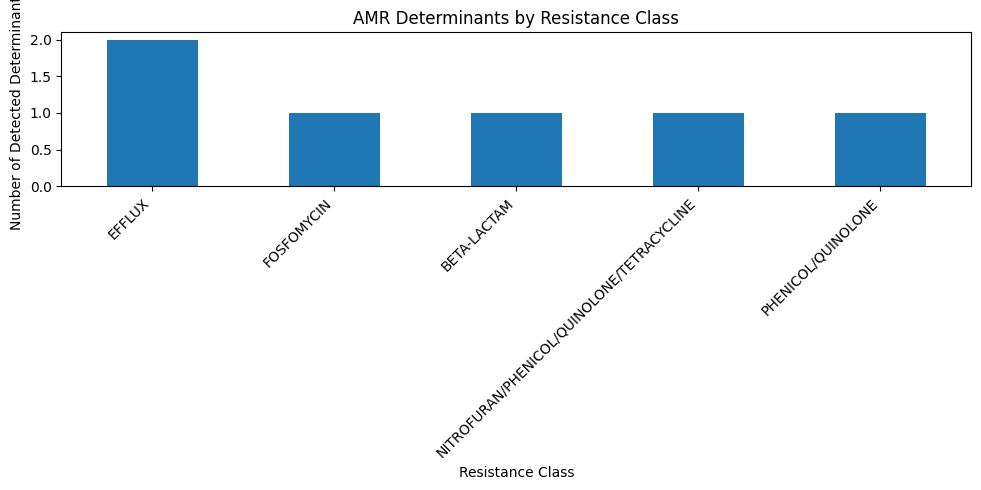

In [ ]:
import matplotlib.pyplot as plt

# Count AMR genes by resistance class
class_counts = amr["Class"].value_counts()

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")

plt.title("AMR Determinants by Resistance Class")
plt.xlabel("Resistance Class")
plt.ylabel("Number of Detected Determinants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# AMR determinants by genomic location

location_counts = amr["Contig id"].value_counts()

print("===== AMR DETERMINANTS BY CONTIG =====")
display(location_counts.to_frame("Number of AMR Determinants"))

===== AMR DETERMINANTS BY CONTIG =====


,Number of AMR Determinants
Contig id,
NC_012731.1,6


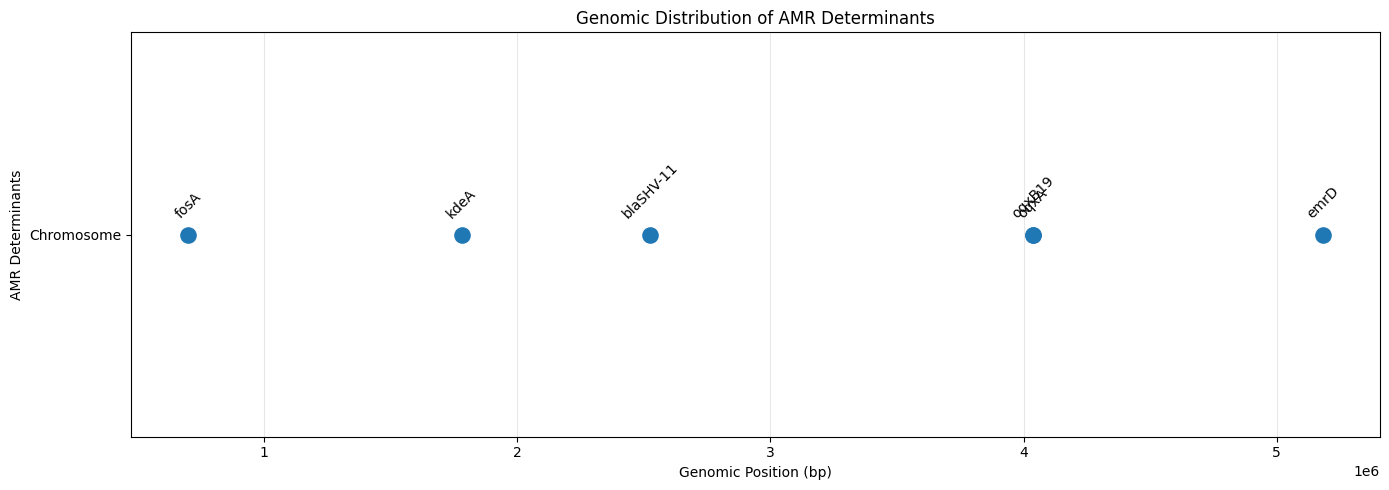

In [ ]:
import matplotlib.pyplot as plt

# Sort AMR determinants by genomic position
amr_plot = amr.sort_values("Start")

plt.figure(figsize=(14, 5))

plt.scatter(
    amr_plot["Start"],
    [1] * len(amr_plot),
    s=120
)

# Add gene labels
for _, row in amr_plot.iterrows():
    plt.annotate(
        row["Element symbol"],
        (row["Start"], 1),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        rotation=45
    )

plt.title("Genomic Distribution of AMR Determinants")
plt.xlabel("Genomic Position (bp)")
plt.ylabel("AMR Determinants")
plt.yticks([1], ["Chromosome"])
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Final AMR evidence table

final_amr = amr[
    [
        "Element symbol",
        "Element name",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference",
        "Contig id",
        "Start",
        "Stop"
    ]
].copy()

# Rename columns for a cleaner research table
final_amr.columns = [
    "Gene",
    "Description",
    "Resistance Class",
    "Subclass",
    "Detection Method",
    "Reference Coverage (%)",
    "Reference Identity (%)",
    "Contig",
    "Start",
    "Stop"
]

print("===== FINAL AMR EVIDENCE TABLE =====")
display(final_amr)

===== FINAL AMR EVIDENCE TABLE =====


,Gene,Description,Resistance Class,Subclass,Detection Method,Reference Coverage (%),Reference Identity (%),Contig,Start,Stop
31,fosA,FosA5 family fosfomycin resistance glutathione...,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.00,NC_012731.1,699857,700273
32,kdeA,multidrug efflux MFS transporter KdeA,EFFLUX,EFFLUX,EXACTX,100.0,100.00,NC_012731.1,1779773,1781002
33,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.00,NC_012731.1,2524621,2525478
43,oqxA,multidrug efflux RND transporter periplasmic a...,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.00,NC_012731.1,4036312,4037484
44,oqxB19,multidrug efflux RND transporter permease subu...,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.00,NC_012731.1,4037511,4040660
45,emrD,multidrug efflux MFS transporter EmrD,EFFLUX,EFFLUX,BLASTX,100.0,99.49,NC_012731.1,5183442,5184623


In [ ]:
# Extract virulence-associated features

virulence = df[df["Type"] == "VIRULENCE"].copy()

virulence_summary = virulence[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

virulence_summary.columns = [
    "Gene",
    "Description",
    "Contig",
    "Start",
    "Stop",
    "Detection Method",
    "Reference Coverage (%)",
    "Reference Identity (%)"
]

print("===== VIRULENCE FACTOR SUMMARY =====")
display(virulence_summary)

===== VIRULENCE FACTOR SUMMARY =====


,Gene,Description,Contig,Start,Stop,Detection Method,Reference Coverage (%),Reference Identity (%)
0,rmpA,mucoid phenotype regulator RmpA,NC_006625.1,10701,11330,EXACTX,100.00,100.00
1,rmpD,mucoid phenotype synthesis protein RmpD,NC_006625.1,11389,11508,EXACTX,100.00,100.00
2,rmpC,mucoid phenotype regulator RmpC,NC_006625.1,11864,12262,BLASTX,100.00,90.23
3,peg-344,DMT family inner membrane transporter PEG344,NC_006625.1,12338,13237,EXACTX,100.00,100.00
4,iroN,siderophore salmochelin receptor IroN,NC_006625.1,13669,15840,EXACTX,100.00,100.00
5,iroD,catecholate siderophore esterase IroD,NC_006625.1,16303,17529,BLASTX,100.00,98.78
6,iroC,salmochelin/enterobactin export ABC transporte...,NC_006625.1,17643,21278,BLASTX,99.51,89.04
7,iroB,salmochelin biosynthesis C-glycosyltransferase...,NC_006625.1,21424,22536,BLASTX,100.00,90.30
26,iutA,ferric aerobactin receptor IutA,NC_006625.1,209682,211868,BLASTX,99.73,89.57
27,iucC,NIS family aerobactin synthetase IucC,NC_006625.1,213246,214976,BLASTX,99.48,92.72


In [ ]:
# Extract stress / metal resistance features

stress = df[df["Type"] == "STRESS"].copy()

stress_summary = stress[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

stress_summary.columns = [
    "Gene",
    "Description",
    "Contig",
    "Start",
    "Stop",
    "Class",
    "Subclass",
    "Detection Method",
    "Reference Coverage (%)",
    "Reference Identity (%)"
]

print("===== STRESS / METAL RESISTANCE SUMMARY =====")
display(stress_summary)

===== STRESS / METAL RESISTANCE SUMMARY =====


,Gene,Description,Contig,Start,Stop,Class,Subclass,Detection Method,Reference Coverage (%),Reference Identity (%)
8,pcoS,copper resistance membrane spanning protein PcoS,NC_006625.1,86272,87669,COPPER,COPPER,BLASTX,100.00,99.14
9,pcoR,copper response regulator transcription factor...,NC_006625.1,87669,88346,COPPER,COPPER,EXACTX,100.00,100.00
10,pcoD,copper resistance inner membrane protein PcoD,NC_006625.1,88404,89330,COPPER,COPPER,BLASTX,100.00,99.35
11,pcoC,copper resistance system metallochaperone PcoC,NC_006625.1,89338,89715,COPPER,COPPER,EXACTX,100.00,100.00
12,pcoB,copper-binding protein PcoB,NC_006625.1,89758,90645,COPPER,COPPER,BLASTX,100.00,99.66
13,pcoA,multicopper oxidase PcoA,NC_006625.1,90654,92468,COPPER,COPPER,BLASTX,100.00,99.83
14,silP,Ag(+)-translocating P-type ATPase SilP,NC_006625.1,94452,96917,SILVER,SILVER,BLASTX,99.64,94.53
15,silA,Cu(+)/Ag(+) efflux RND transporter permease su...,NC_006625.1,97553,100696,COPPER/SILVER,COPPER/SILVER,BLASTX,100.00,98.85
16,silB,Cu(+)/Ag(+) efflux RND transporter periplasmic...,NC_006625.1,100710,101999,COPPER/SILVER,COPPER/SILVER,BLASTX,100.00,98.14
17,silF,Cu(+)/Ag(+) efflux RND transporter periplasmic...,NC_006625.1,102116,102475,COPPER/SILVER,COPPER/SILVER,BLASTX,100.00,94.17


In [ ]:
%%bash

source /usr/local/etc/profile.d/conda.sh
conda activate amrfinder

echo "===== KLEBSIELLA PNEUMONIAE AMR MUTATION SEARCH ====="

amrfinder \
    -n salmonella_test.fasta \
    -O Klebsiella_pneumoniae \
    --plus \
    -o amr_klebsiella_mutations.tsv

echo ""
echo "===== MUTATION / AMR RESULTS ====="

cat amr_klebsiella_mutations.tsv

===== KLEBSIELLA PNEUMONIAE AMR MUTATION SEARCH =====

===== MUTATION / AMR RESULTS =====
Protein id	Contig id	Start	Stop	Strand	Element symbol	Element name	Scope	Type	Subtype	Class	Subclass	Method	Target length	Reference sequence length	% Coverage of reference	% Identity to reference	Alignment length	Closest reference accession	Closest reference name	HMM accession	HMM description
NA	NC_006625.1	10701	11330	+	rmpA	mucoid phenotype regulator RmpA	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	210	210	100.00	100.00	210	AMA27886.1	mucoid phenotype regulator RmpA	NA	NA
NA	NC_006625.1	11389	11508	+	rmpD	mucoid phenotype synthesis protein RmpD	plus	VIRULENCE	VIRULENCE	NA	NA	EXACTX	40	40	100.00	100.00	40	QIK04195.1	mucoid phenotype synthesis protein RmpD	NA	NA
NA	NC_006625.1	11864	12262	+	rmpC	mucoid phenotype regulator RmpC	plus	VIRULENCE	VIRULENCE	NA	NA	BLASTX	133	133	100.00	90.23	133	AIK83625.1	mucoid phenotype regulator RmpC	NA	NA
NA	NC_006625.1	12338	13237	+	peg-344	DMT family inner membrane tran

Running: amrfinder -n salmonella_test.fasta -O Klebsiella_pneumoniae --plus -o amr_klebsiella_mutations.tsv
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
AMRFinder translated nucleotide and mutation search
Running tblastn
Running blastn
Making report
amrfinder took 342 seconds to complete


In [ ]:
mutation_results = pd.read_csv(
    "amr_klebsiella_mutations.tsv",
    sep="\t"
)

amr_mutation_hits = mutation_results[
    mutation_results["Type"] == "AMR"
].copy()

print("===== KLEBSIELLA AMR / MUTATION HITS =====")

display(amr_mutation_hits)

===== KLEBSIELLA AMR / MUTATION HITS =====


,Protein id,Contig id,Start,Stop,Strand,Element symbol,Element name,Scope,Type,Subtype,...,Method,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name,HMM accession,HMM description
31,NaN,NC_012731.1,699857,700273,+,fosA,FosA5 family fosfomycin resistance glutathione...,core,AMR,AMR,...,EXACTX,139,139,100.0,100.00,139,WP_004146118.1,FosA5 family fosfomycin resistance glutathione...,NaN,NaN
32,NaN,NC_012731.1,2524621,2525478,-,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,core,AMR,AMR,...,ALLELEX,286,286,100.0,100.00,286,WP_004176269.1,broad-spectrum class A beta-lactamase SHV-11,NaN,NaN
42,NaN,NC_012731.1,4036312,4037484,+,oqxA,multidrug efflux RND transporter periplasmic a...,core,AMR,AMR,...,EXACTX,391,391,100.0,100.00,391,WP_002914189.1,multidrug efflux RND transporter periplasmic a...,NaN,NaN
43,NaN,NC_012731.1,4037511,4040660,+,oqxB19,multidrug efflux RND transporter permease subu...,core,AMR,AMR,...,ALLELEX,1050,1050,100.0,100.00,1050,WP_004149399.1,multidrug efflux RND transporter permease subu...,NaN,NaN
44,NaN,NC_012731.1,5183442,5184623,+,emrD,multidrug efflux MFS transporter EmrD,plus,AMR,AMR,...,BLASTX,394,394,100.0,99.49,394,ACN65732.1,multidrug efflux MFS transporter EmrD,NaN,NaN


In [ ]:
# Check for mutation-related records

print("===== MUTATION-RELATED RECORDS =====")

mutation_keywords = (
    mutation_results.astype(str)
    .apply(lambda col: col.str.contains(
        "mutation|mutant|variant|substitution",
        case=False,
        na=False
    ))
    .any(axis=1)
)

mutation_only = mutation_results[mutation_keywords]

if len(mutation_only) == 0:
    print("No mutation-specific records detected in the AMRFinderPlus output.")
else:
    display(mutation_only)

===== MUTATION-RELATED RECORDS =====
No mutation-specific records detected in the AMRFinderPlus output.


In [ ]:
# ===== FINAL PROJECT SUMMARY =====

total_amr = len(amr)
total_virulence = len(virulence)
total_stress = len(stress)
total_mutations = len(mutation_only)

print("==========================================")
print("   GENOTYPIC AMR ANALYSIS SUMMARY")
print("   Klebsiella pneumoniae NTUH-K2044")
print("==========================================")

print(f"AMR determinants detected       : {total_amr}")
print(f"Virulence-associated features  : {total_virulence}")
print(f"Stress/metal resistance        : {total_stress}")
print(f"Mutation-specific records      : {total_mutations}")

print("\n===== AMR GENES =====")
print(", ".join(amr["Element symbol"].tolist()))

print("\n===== AMR CONTIG DISTRIBUTION =====")
print(amr["Contig id"].value_counts().to_string())

print("\n===== MUTATION RESULT =====")
if total_mutations == 0:
    print("No mutation-specific records detected.")
else:
    print(f"{total_mutations} mutation-related records detected.")

   GENOTYPIC AMR ANALYSIS SUMMARY
   Klebsiella pneumoniae NTUH-K2044
AMR determinants detected       : 6
Virulence-associated features  : 21
Stress/metal resistance        : 19
Mutation-specific records      : 0

===== AMR GENES =====
fosA, kdeA, blaSHV-11, oqxA, oqxB19, emrD

===== AMR CONTIG DISTRIBUTION =====
Contig id
NC_012731.1    6

===== MUTATION RESULT =====
No mutation-specific records detected.


In [ ]:
# ===== SAVE ANALYSIS RESULTS =====

import os

# Create project folders
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Save result tables
final_amr.to_csv("results/AMR_evidence_table.csv", index=False)
virulence_summary.to_csv("results/Virulence_factors.csv", index=False)
stress_summary.to_csv("results/Stress_metal_resistance.csv", index=False)

# Save mutation analysis
amr_mutation_hits.to_csv(
    "results/AMR_mutation_results.csv",
    index=False
)

# Save overall summary
summary = pd.DataFrame({
    "Analysis": [
        "AMR determinants",
        "Virulence-associated features",
        "Stress/metal resistance",
        "Mutation-specific records"
    ],
    "Count": [
        total_amr,
        total_virulence,
        total_stress,
        total_mutations
    ]
})

summary.to_csv("results/Project_summary.csv", index=False)

print("===== FILES SAVED =====")
for root, dirs, files in os.walk("results"):
    for file in files:
        print(os.path.join(root, file))

===== FILES SAVED =====
results/Stress_metal_resistance.csv
results/AMR_evidence_table.csv
results/AMR_mutation_results.csv
results/Project_summary.csv
results/Virulence_factors.csv


# Results

## Virulence-associated Features

The analysis identified **21 virulence-associated features**. These included features associated with:

- Mucoid phenotype regulation
- Salmochelin
- Aerobactin
- Yersiniabactin

Several of these features were located on plasmid **NC_006625.1**.

## Stress and Metal Resistance

A total of **19 stress/metal-associated features** were detected. These included systems associated with:

- Copper
- Silver
- Tellurium
- Other metal-associated stress responses

Most of these features were located on plasmid **NC_006625.1**.

## Mutation Analysis

An organism-specific AMRFinderPlus analysis was performed for *Klebsiella pneumoniae*. No mutation-specific records were detected in the resulting AMRFinderPlus output.

## Overall Summary

| Feature | Number |
|---|---:|
| AMR determinants | 6 |
| Virulence-associated features | 21 |
| Stress/metal resistance features | 19 |
| Mutation-specific records | 0 |

## Interpretation

The results showed that the genome contained several AMR genes along with other characteristics such as stress/metal resistance and virulence factors. The AMR genes were found in the chromosomes while others like virulence factors and stress/metal resistance were present in the plasmids.

However, genotypic identification of AMR genes cannot guarantee that the bacteria have an antimicrobial resistance profile. Therefore, it is important to conduct phenotypic antimicrobial susceptibility testing for the confirmation of AMR profile.